In [3]:
import earthaccess
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.animation as animation

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.animation import FuncAnimation, PillowWriter
from datetime import datetime, timedelta
import pandas as pd

# Authenticate with NASA Earthdata
earthaccess.login()


/home/zhe2/anaconda3/envs/ocean/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [51]:
tspan = ("2025-02-06", "2025-02-06")
bbox = (-110, 6, -85, 25)
clouds = (0, 70)

results_bgc = earthaccess.search_data(
    short_name="PACE_OCI_L2_BGC",
    temporal=tspan,
    bounding_box=bbox,
    cloud_cover=clouds,
)
results_aop = earthaccess.search_data(
    short_name="PACE_OCI_L2_AOP",
    temporal=tspan,
    bounding_box=bbox,
    cloud_cover=clouds,
)

/home/zhe2/anaconda3/envs/ocean/lib/python3.14/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


In [52]:
len(results_bgc)

4

In [53]:
# read the first granule of results_bgc
granule_bgc = earthaccess.open(results_aop)
# open data tree
dt_bgc = xr.open_datatree(granule_bgc[-1])
# merge
ds_bgc = xr.merge(dt_bgc.to_dict().values())
chlor_a = ds_bgc['nflh'].values


/home/zhe2/anaconda3/envs/ocean/lib/python3.14/site-packages/earthaccess/store.py:516: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)
QUEUEING TASKS | : 100%|██████████| 4/4 [00:00<00:00, 381.28it/s]
PROCESSING TASKS | : 100%|██████████| 4/4 [00:01<00:00,  3.00it/s]
COLLECTING RESULTS | : 100%|██████████| 4/4 [00:00<00:00, 107546.26it/s]
/tmp/ipykernel_3189925/647507613.py:4: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedelt

In [54]:
buffer_bnd = .25
BBOX = bbox
lon_min = BBOX[0] - buffer_bnd
lon_max = BBOX[2] + buffer_bnd
lat_min = BBOX[1] - buffer_bnd
lat_max = BBOX[3] + buffer_bnd
extent = [lon_min, lon_max, lat_min, lat_max]

/tmp/ipykernel_3189925/1791053525.py:12: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  dt_bgc = xr.open_datatree(granule_bgc[i])
/tmp/ipykernel_3189925/1791053525.py:12: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To c

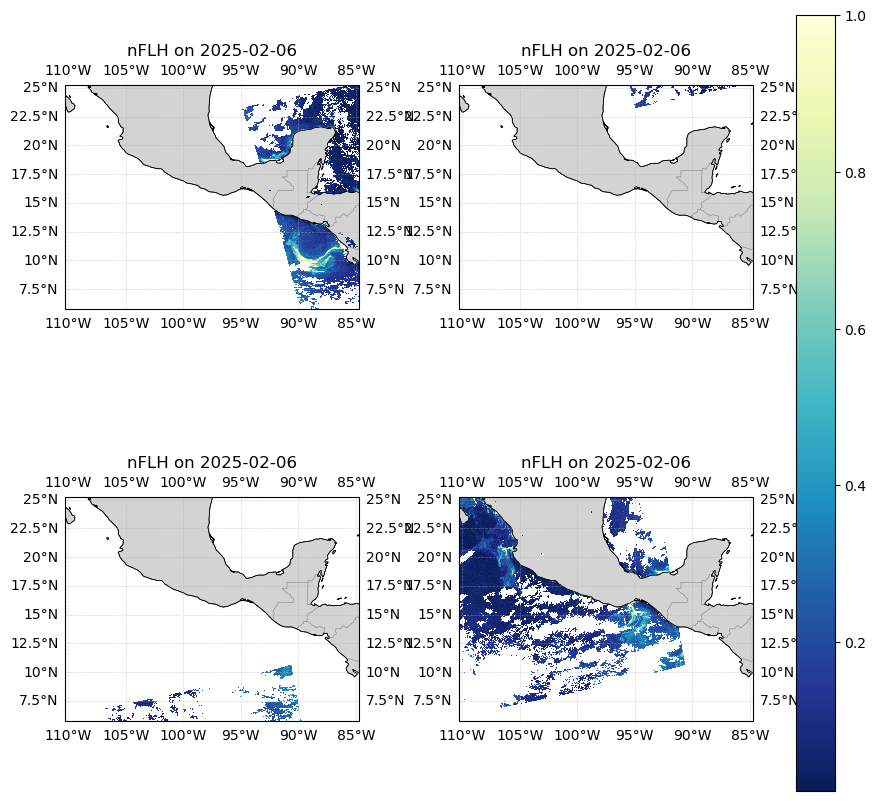

In [55]:
# in sequence, plotting out chlor_a data of each granule

# FIX: Can't use 'projection' argument in plt.subplots; must create subplot axes with projection manually.
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()
for i in range(len(results_bgc)):
    # Replace normal axes with GeoAxes with Cartopy projection
    fig.delaxes(axes[i])
    ax = fig.add_subplot(2, 2, i + 1, projection=ccrs.PlateCarree())
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    # Reload data
    dt_bgc = xr.open_datatree(granule_bgc[i])
    ds_bgc = xr.merge(dt_bgc.to_dict().values())
    chlor_a = ds_bgc['nflh'].values
    lat = ds_bgc['latitude'].values
    lon = ds_bgc['longitude'].values
    
    # Plot data
    mesh = ax.pcolormesh(lon, lat, chlor_a, transform=ccrs.PlateCarree(),
                         cmap="YlGnBu_r", vmin=0.01, vmax=1.0)
    date = datetime.strptime(str(granule_bgc[i])[109:117], '%Y%m%d')
    ax.set_title(f"nFLH on {date.strftime('%Y-%m-%d')}")
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
    ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
    # Optionally add colorbar per subplot (or globally afterwards)
    plt.tight_layout()
# Optionally add a single colorbar for all subplots:
fig.colorbar(mesh, ax=fig.get_axes(), orientation='vertical', shrink=0.8)
